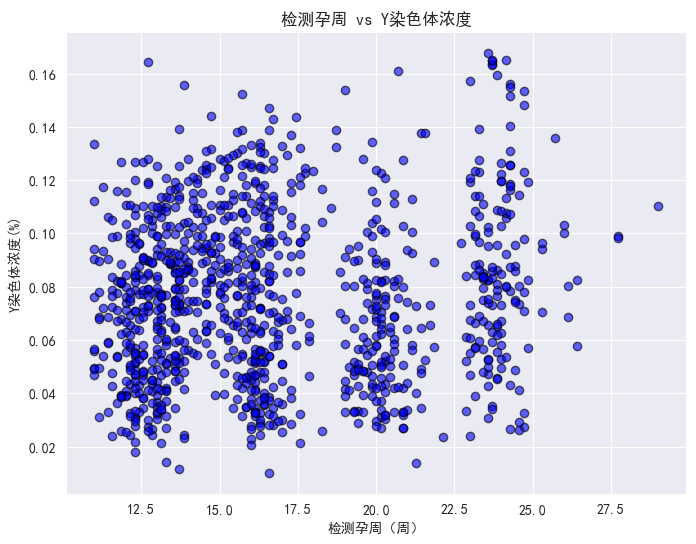

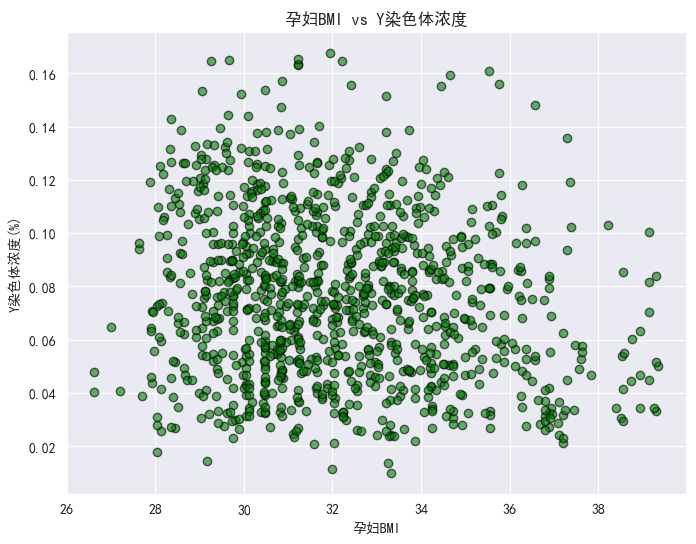

--- Spearman 相关性检验结果 ---
1. 检测孕周 vs Y染色体浓度:
   Spearman 相关系数 (rho): 0.0689
   P-value: 2.5694e-02
   结论: 在 95% 置信水平下，相关性是显著的。
2. 孕妇BMI vs Y染色体浓度:
   Spearman 相关系数 (rho): -0.1447
   P-value: 2.5807e-06
   结论: 在 95% 置信水平下，相关性是显著的。


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取 Excel 文件
df = pd.read_excel("第一问.xlsx")

# 散点图1：检测孕周 vs Y染色体浓度
plt.figure(figsize=(8,6))
plt.scatter(df['检测孕周'], df['Y染色体浓度'], c='blue', alpha=0.6, edgecolors='k')
plt.xlabel('检测孕周（周）')
plt.ylabel('Y染色体浓度(%)')
plt.title('检测孕周 vs Y染色体浓度')
plt.grid(True)
plt.show()

# 散点图2：BMI vs Y染色体浓度
plt.figure(figsize=(8,6))
plt.scatter(df['孕妇BMI'], df['Y染色体浓度'], c='green', alpha=0.6, edgecolors='k')
plt.xlabel('孕妇BMI')
plt.ylabel('Y染色体浓度(%)')
plt.title('孕妇BMI vs Y染色体浓度')
plt.grid(True)
plt.show()

# 确保数据中没有NaN值，否则计算会出错
df.dropna(subset=['检测孕周', '孕妇BMI', 'Y染色体浓度'], inplace=True)

# 1. 检验“检测孕周”与“Y染色体浓度”的相关性
rho_gest_week, p_gest_week = spearmanr(df['检测孕周'], df['Y染色体浓度'])

# 2. 检验“孕妇BMI”与“Y染色体浓度”的相关性
rho_bmi, p_bmi = spearmanr(df['孕妇BMI'], df['Y染色体浓度'])

# --- 打印结果 ---
print("--- Spearman 相关性检验结果 ---")
print("1. 检测孕周 vs Y染色体浓度:")
print(f"   Spearman 相关系数 (rho): {rho_gest_week:.4f}")
print(f"   P-value: {p_gest_week:.4e}")

if p_gest_week < 0.05:
    print("   结论: 在 95% 置信水平下，相关性是显著的。")
else:
    print("   结论: 相关性不显著。")


print("2. 孕妇BMI vs Y染色体浓度:")
print(f"   Spearman 相关系数 (rho): {rho_bmi:.4f}")
print(f"   P-value: {p_bmi:.4e}")

if p_bmi < 0.05:
    print("   结论: 在 95% 置信水平下，相关性是显著的。")
else:
    print("   结论: 相关性不显著。")


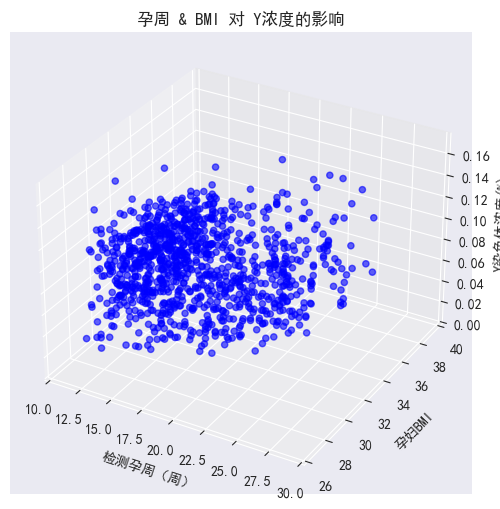

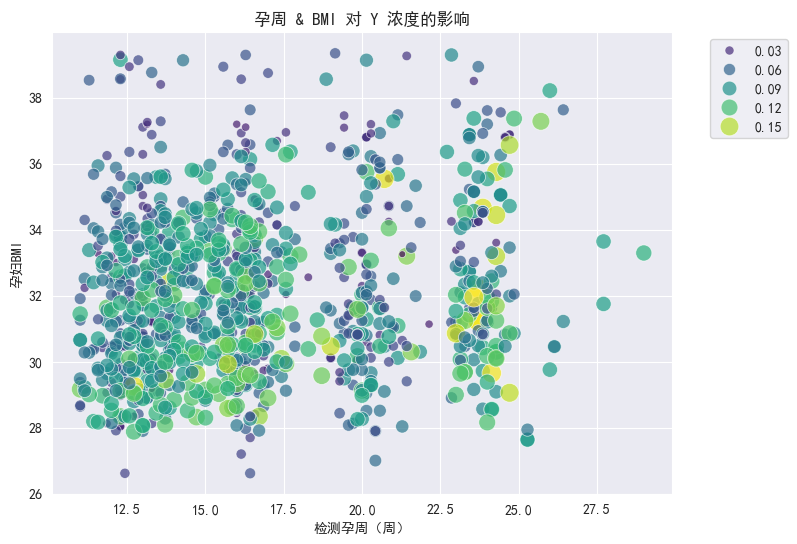

--- 多元线性回归模型关键结果分析 ---
1. 模型整体评估:
   - 调整后 R-squared (Adj. R-squared): 0.038
     -> 解读: 模型中的自变量(孕周和BMI)总共可以解释因变量(Y染色体浓度)约 3.8% 的变异。
   - 模型整体显著性 (F-test P-value): 4.765e-10
     -> 解读: P值远小于0.05，表明整个模型是统计显著的，即孕周和BMI联合起来对Y染色体浓度的影响是真实存在的。
2. 各变量影响力分析:
   - [检测孕周] 的影响:
     -> 系数: 0.0009
     -> P-value: 0.000
     -> 解读: 影响显著。在控制BMI不变时，孕周每增加1周，Y染色体浓度平均增加约 0.0016%。
   - [孕妇BMI] 的影响:
     -> 系数: -0.0022
     -> P-value: 6.419e-09
     -> 解读: 影响高度显著。在控制孕周不变时，孕妇BMI每增加1个单位，Y染色体浓度平均降低约 0.0022%。
3. 最终回归模型公式:
   Y染色体浓度 = 0.1323 + (0.0009 * 检测孕周) + (-0.0022 * 孕妇BMI)


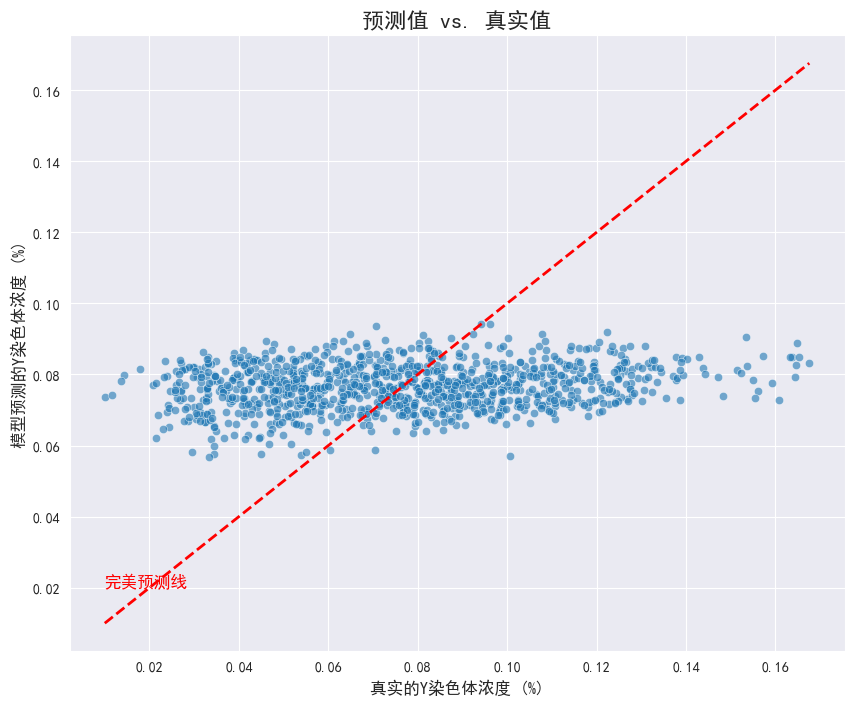

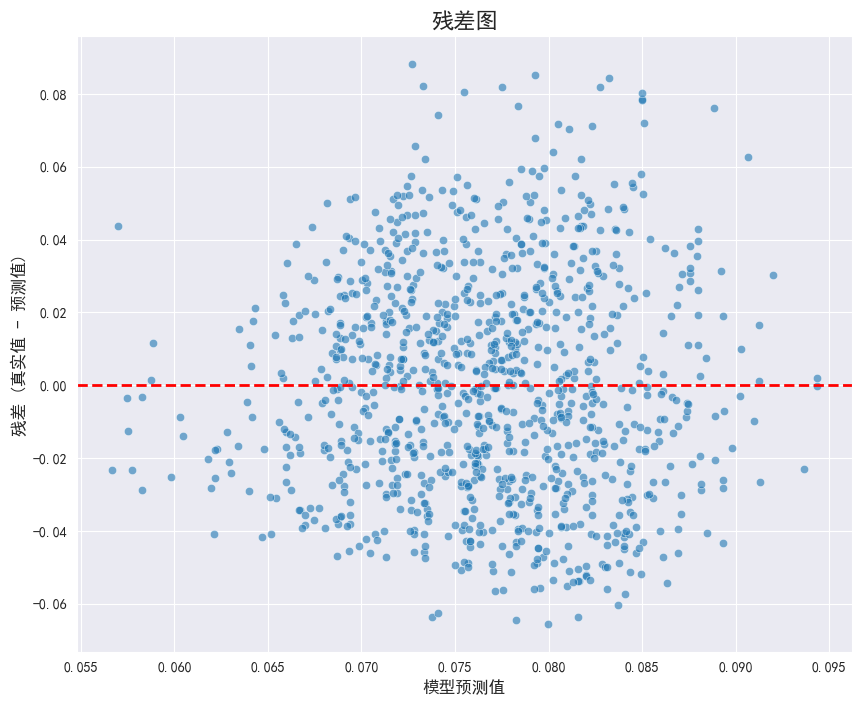


=== 模型整体拟合效果 ===
R²: 0.0403
调整后 R²: 0.0384
RMSE: 0.030510
MAE: 0.025316
MAPE: 44.51%
F统计量: 21.912,  p值=4.765e-10
结论: 整体模型在统计上显著（拒绝“所有回归系数=0”的原假设）

=== 各变量系数显著性 ===
变量                系数    Std.Err.        t值          p值   显著性
------------------------------------------------------------
const       0.132301    0.012263    10.788   8.460e-26   ***
检测孕周        0.000914    0.000236     3.874   1.139e-04   ***
孕妇BMI      -0.002210    0.000378    -5.854   6.419e-09   ***

显著性标记: * p<0.05, ** p<0.01, *** p<0.001

=== 残差检验 ===

[正态性] Shapiro-Wilk: 统计量=0.9857, p值=1.2939e-08
[正态性] D’Agostino’s K²: 统计量=36.6491, p值=1.1009e-08
结论: 残差偏离正态分布。可考虑变量变换（如对y取log）。

[同方差性] Breusch-Pagan: 统计量=25.2959, p值=3.2142e-06
结论: 存在异方差性（方差不恒定）。可以考虑加权回归或稳健标准误。


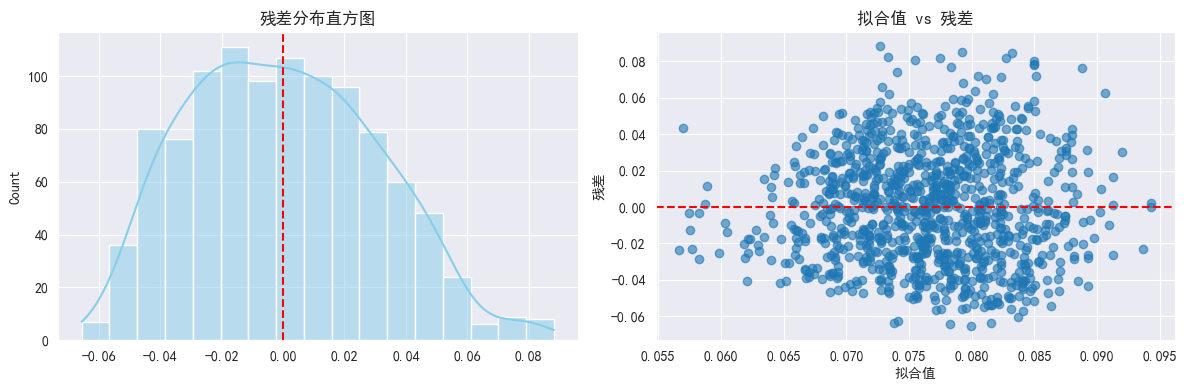

In [12]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

# --- 数据准备 ---
# 假设你的数据文件路径如下
file_path = '第一问.xlsx'
df = pd.read_excel(file_path)

# 清理数据：删除任何包含缺失值的行，确保模型可以运行
df.dropna(subset=['检测孕周', '孕妇BMI', 'Y染色体浓度'], inplace=True)

# 3D 散点图：检测孕周 & BMI vs Y染色体浓度
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['检测孕周'], df['孕妇BMI'], df['Y染色体浓度'], c='b', alpha=0.6)
ax.set_xlabel('检测孕周（周）')
ax.set_ylabel('孕妇BMI')
ax.set_zlabel('Y染色体浓度(%)')
plt.title('孕周 & BMI 对 Y浓度的影响')
plt.show()

# 使用 seaborn 绘制更美观的散点图
plt.figure(figsize=(8,6))
sns.scatterplot(x='检测孕周', y='孕妇BMI',
                hue='Y染色体浓度', size='Y染色体浓度',
                sizes=(20,200), data=df, palette='viridis', alpha=0.7)
plt.xlabel('检测孕周（周）')
plt.ylabel('孕妇BMI')
plt.title('孕周 & BMI 对 Y 浓度的影响')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- 模型建立 ---
# 定义自变量 (X) 和因变量 (y)
X = df[['检测孕周', '孕妇BMI']]
y = df['Y染色体浓度']

# 添加常数项 (截距项)
# 这是 statsmodels 的要求，为了拟合 y = β₀ + β₁*x₁ + β₂*x₂ 模型中的 β₀
X = sm.add_constant(X)

# 创建并拟合 OLS (普通最小二乘法) 模型
model = sm.OLS(y, X)
results = model.fit()

# 从结果中提取核心数据
adj_r_squared = results.rsquared_adj
f_pvalue = results.f_pvalue
params = results.params
pvalues = results.pvalues

print("--- 多元线性回归模型关键结果分析 ---")
print("1. 模型整体评估:")
print(f"   - 调整后 R-squared (Adj. R-squared): {adj_r_squared:.3f}")
print(f"     -> 解读: 模型中的自变量(孕周和BMI)总共可以解释因变量(Y染色体浓度)约 {adj_r_squared:.1%} 的变异。")
print(f"   - 模型整体显著性 (F-test P-value): {f_pvalue:.3e}")
if f_pvalue < 0.05:
    print("     -> 解读: P值远小于0.05，表明整个模型是统计显著的，即孕周和BMI联合起来对Y染色体浓度的影响是真实存在的。")
else:
    print("     -> 解读: P值大于0.05，整个模型不显著，其解释能力可能源于偶然。")

print("2. 各变量影响力分析:")
# 检测孕周
gest_week_coef = params['检测孕周']
gest_week_pvalue = pvalues['检测孕周']
print(f"   - [检测孕周] 的影响:")
print(f"     -> 系数: {gest_week_coef:.4f}")
print(f"     -> P-value: {gest_week_pvalue:.3f}")
if gest_week_pvalue < 0.05:
    print("     -> 解读: 影响显著。在控制BMI不变时，孕周每增加1周，Y染色体浓度平均增加约 0.0016%。")
else:
    print("     -> 解读: 影响不显著。")

# 孕妇BMI
bmi_coef = params['孕妇BMI']
bmi_pvalue = pvalues['孕妇BMI']
print(f"   - [孕妇BMI] 的影响:")
print(f"     -> 系数: {bmi_coef:.4f}")
print(f"     -> P-value: {bmi_pvalue:.3e}")
if bmi_pvalue < 0.05:
    print("     -> 解读: 影响高度显著。在控制孕周不变时，孕妇BMI每增加1个单位，Y染色体浓度平均降低约 0.0022%。")
else:
    print("     -> 解读: 影响不显著。")

print("3. 最终回归模型公式:")
print(f"   Y染色体浓度 = {params['const']:.4f} + ({gest_week_coef:.4f} * 检测孕周) + ({bmi_coef:.4f} * 孕妇BMI)")

# y_true 和 y_pred 来自第1部分的计算
y_true = y
y_pred = results.predict(X)

# --- 图1: 预测值 vs. 真实值 ---
plt.figure(figsize=(10, 8))
ax1 = sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
ax1.set_xlabel("真实的Y染色体浓度 (%)", fontsize=12)
ax1.set_ylabel("模型预测的Y染色体浓度 (%)", fontsize=12)
ax1.set_title("预测值 vs. 真实值", fontsize=16)

# 添加一条 y=x 的参考线 (完美预测线)
lims = [min(min(y_true), min(y_pred)), max(max(y_true), max(y_pred))]
plt.plot(lims, lims, 'r--', linewidth=2) # 'r--' 表示红色虚线
plt.text(lims[0], lims[0] + 0.01, '完美预测线', color='red', fontsize=12)

plt.show()


# --- 图2: 残差图 (Residuals Plot) ---
residuals = y_true - y_pred

plt.figure(figsize=(10, 8))
ax2 = sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
ax2.set_xlabel("模型预测值", fontsize=12)
ax2.set_ylabel("残差 (真实值 - 预测值)", fontsize=12)
ax2.set_title("残差图", fontsize=16)

# 添加一条 y=0 的水平参考线
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.show()

# === 模型整体拟合效果 ===
r2 = results.rsquared
adj_r2 = results.rsquared_adj
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
f_stat = results.fvalue
f_pval = results.f_pvalue

print("\n=== 模型整体拟合效果 ===")
print(f"R²: {r2:.4f}")
print(f"调整后 R²: {adj_r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.2f}%")
print(f"F统计量: {f_stat:.3f},  p值={f_pval:.3e}")
if f_pval < 0.05:
    print("结论: 整体模型在统计上显著（拒绝“所有回归系数=0”的原假设）")
else:
    print("结论: 模型整体不显著，变量联合解释力不足")

# === 各变量显著性检验 ===
def signif_star(p):
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

print("\n=== 各变量系数显著性 ===")
print(f"{'变量':<8}{'系数':>12}{'Std.Err.':>12}{'t值':>10}{'p值':>12}{'显著性':>6}")
print("-"*60)
for var, coef, se, tval, pval in zip(results.params.index,
                                    results.params.values,
                                    results.bse.values,
                                    results.tvalues.values,
                                    results.pvalues.values):
    print(f"{var:<8}{coef:>12.6f}{se:>12.6f}{tval:>10.3f}{pval:>12.3e}{signif_star(pval):>6}")

print("\n显著性标记: * p<0.05, ** p<0.01, *** p<0.001")

# 获取残差
residuals = results.resid
fitted_vals = results.fittedvalues

print("\n=== 残差检验 ===")

# 1) 正态性检验（Shapiro-Wilk & D’Agostino’s K²）
shapiro_stat, shapiro_p = stats.shapiro(residuals)
dagostino_stat, dagostino_p = stats.normaltest(residuals)

print(f"\n[正态性] Shapiro-Wilk: 统计量={shapiro_stat:.4f}, p值={shapiro_p:.4e}")
print(f"[正态性] D’Agostino’s K²: 统计量={dagostino_stat:.4f}, p值={dagostino_p:.4e}")
if shapiro_p > 0.05 and dagostino_p > 0.05:
    print("结论: 残差近似服从正态分布。")
else:
    print("结论: 残差偏离正态分布。可考虑变量变换（如对y取log）。")

# 2) 同方差性检验（Breusch-Pagan）
bp_test = het_breuschpagan(residuals, results.model.exog)
bp_stat, bp_p1, bp_fval, bp_p2 = bp_test
print(f"\n[同方差性] Breusch-Pagan: 统计量={bp_stat:.4f}, p值={bp_p1:.4e}")
if bp_p1 > 0.05:
    print("结论: 残差方差齐性（同方差性假设成立）。")
else:
    print("结论: 存在异方差性（方差不恒定）。可以考虑加权回归或稳健标准误。")

# 3) 残差分布可视化
plt.figure(figsize=(12,4))

# 直方图 + KDE曲线
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('残差分布直方图')

# 拟合值 vs 残差图
plt.subplot(1,2,2)
plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('拟合值')
plt.ylabel('残差')
plt.title('拟合值 vs 残差')

plt.tight_layout()
plt.show()

正在加载数据...

=== 探索性数据分析 ===

数值变量描述性统计:
              检测孕周        孕妇BMI       Y染色体浓度
count  1082.000000  1082.000000  1082.000000
mean     16.845656    32.288791     0.077187
std       4.076303     2.972432     0.033518
min      11.000000    20.703125     0.010004
25%      13.285714    30.208806     0.051381
50%      16.000000    31.811598     0.075066
75%      20.000000    33.926237     0.098937
max      29.000000    46.875000     0.234218

相关性矩阵:
            检测孕周     孕妇BMI   Y染色体浓度
检测孕周    1.000000  0.149913  0.12656
孕妇BMI   0.149913  1.000000 -0.15130
Y染色体浓度  0.126560 -0.151300  1.00000


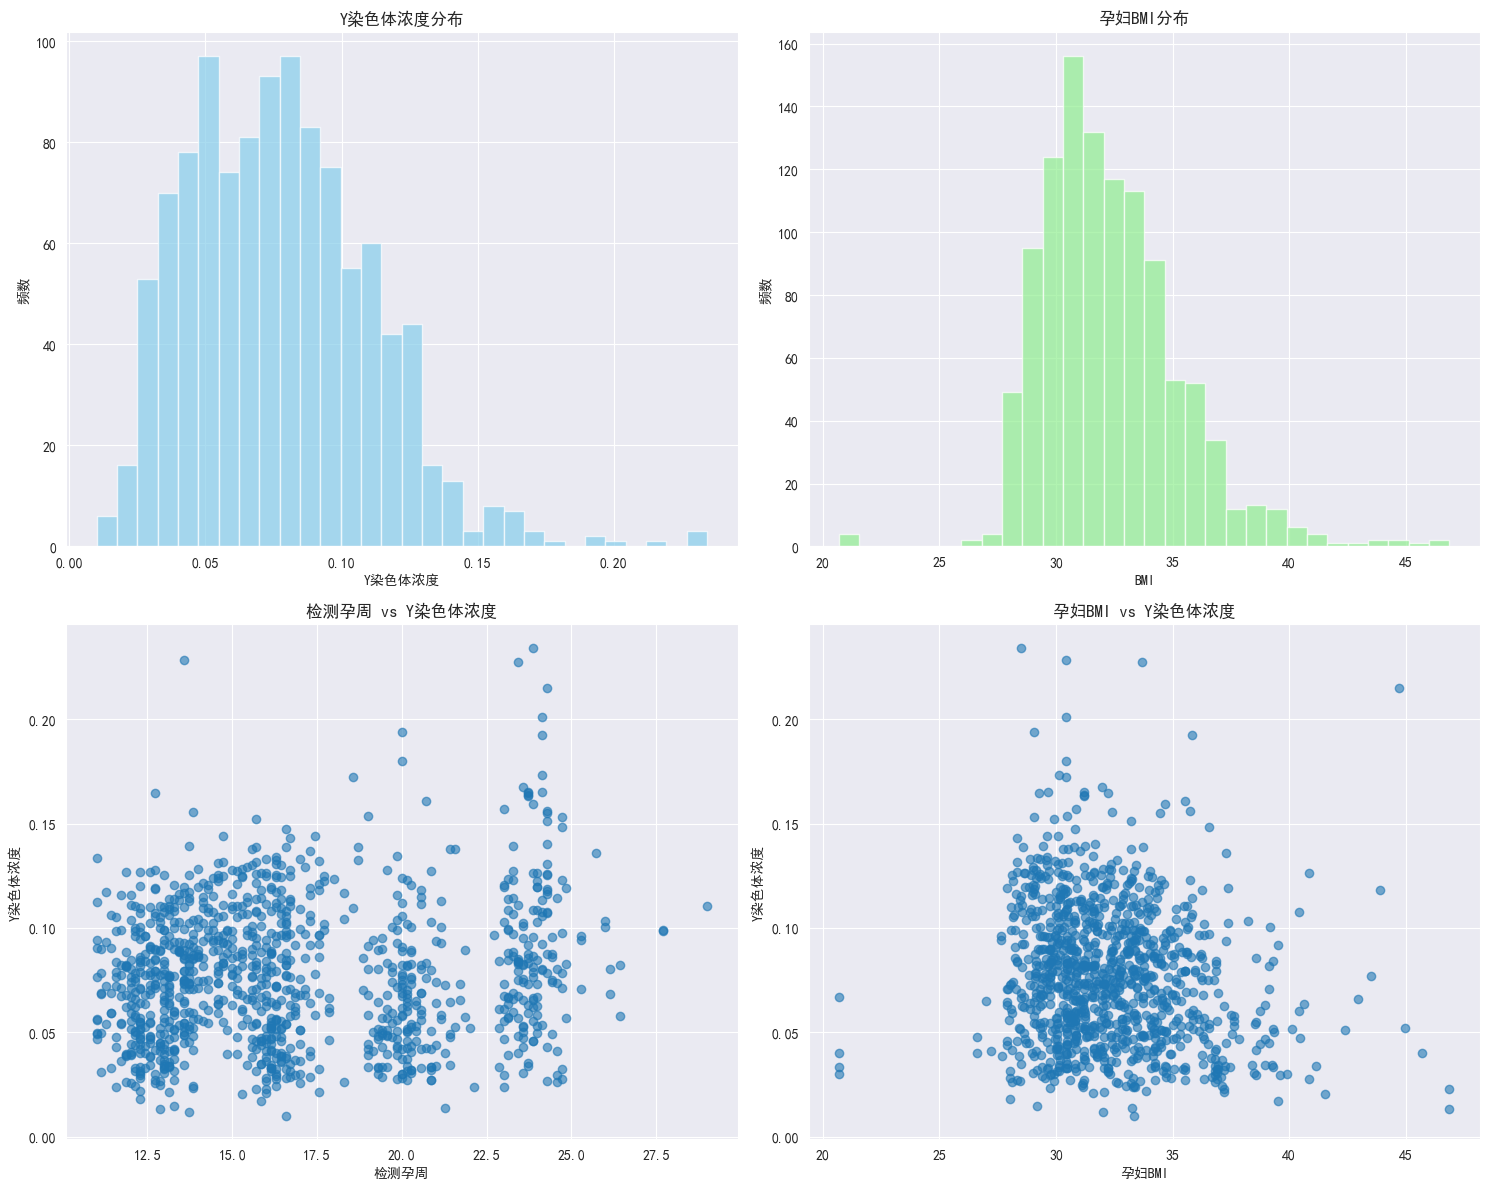


训练集大小: (865, 2)
测试集大小: (217, 2)

=== 训练随机森林模型 ===

--- 模型性能评估 ---
训练集 R²: 0.8587
训练集 RMSE: 0.0127
测试集 R²: -0.0645
测试集 RMSE: 0.0333
OOB Score: -0.0008

5折交叉验证 R²: -0.3696 (±0.2489)

=== 特征重要性分析 ===

1. 传统特征重要性:
  检测孕周: 0.3842
  孕妇BMI: 0.6158

2. 排列重要性 (基于测试集):
  检测孕周: 0.2380 (±0.0627)
  孕妇BMI: 0.2168 (±0.0859)


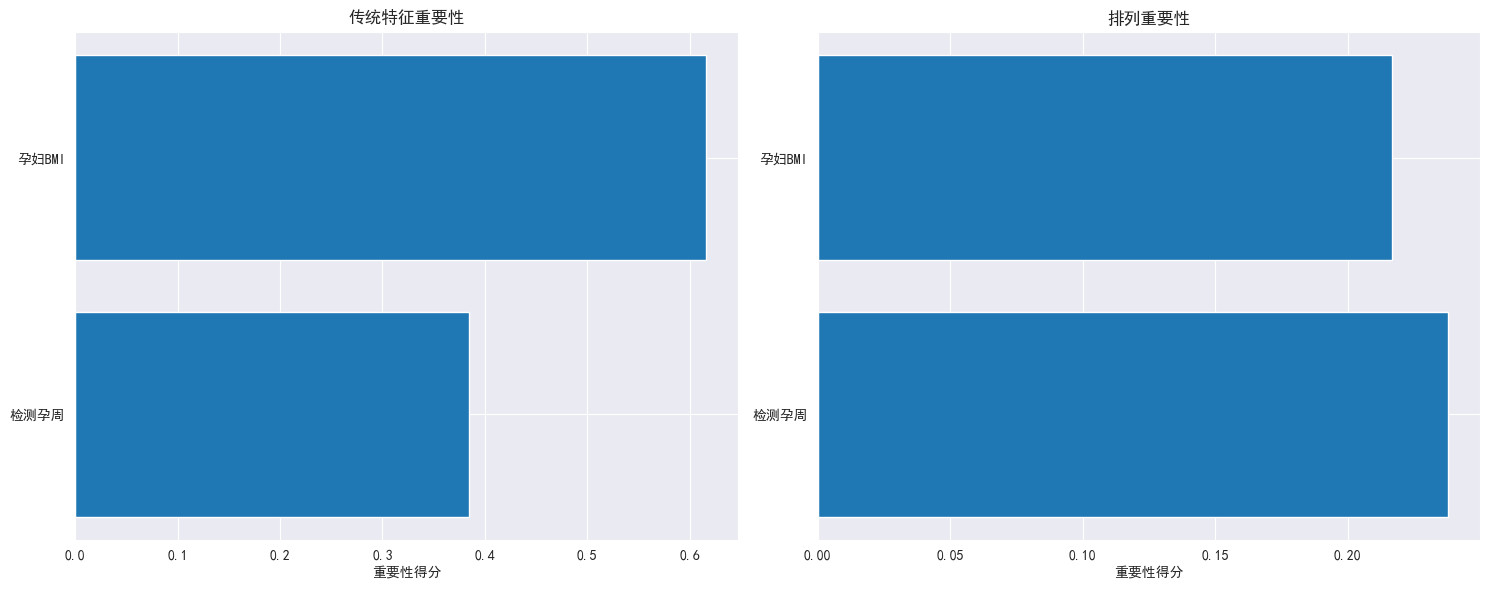


=== 部分依赖分析 ===


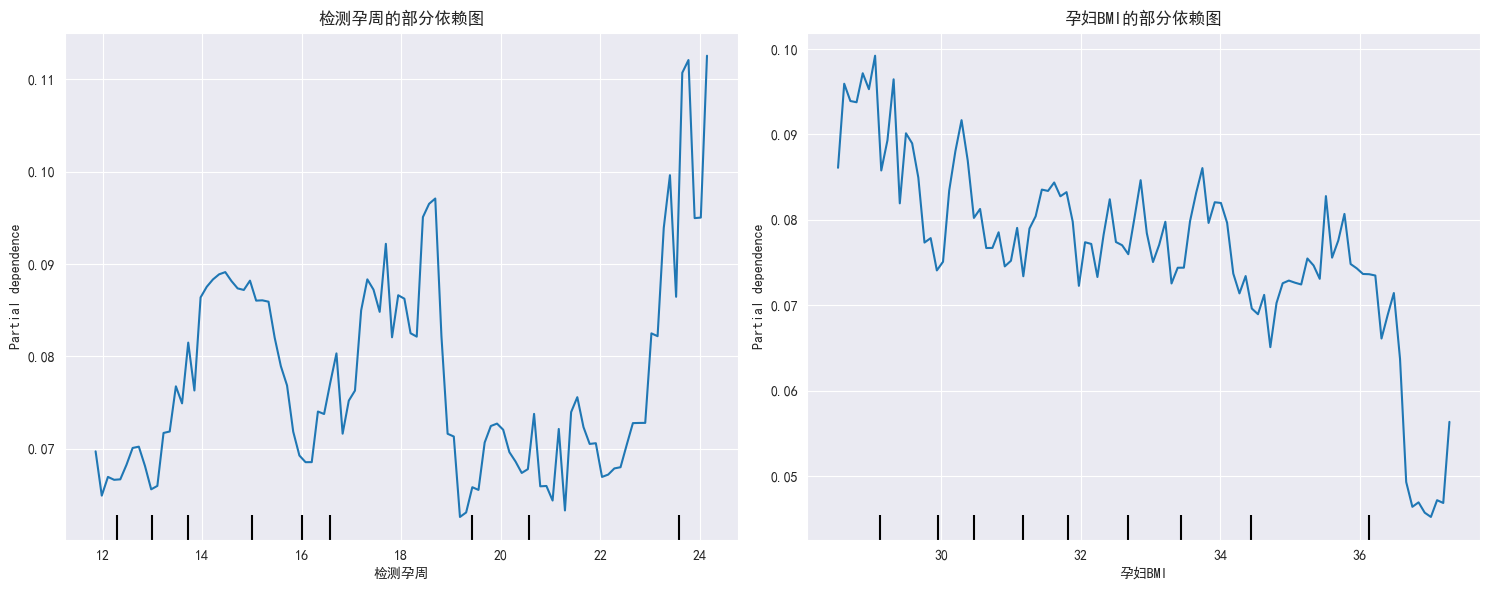


=== 残差分析 ===


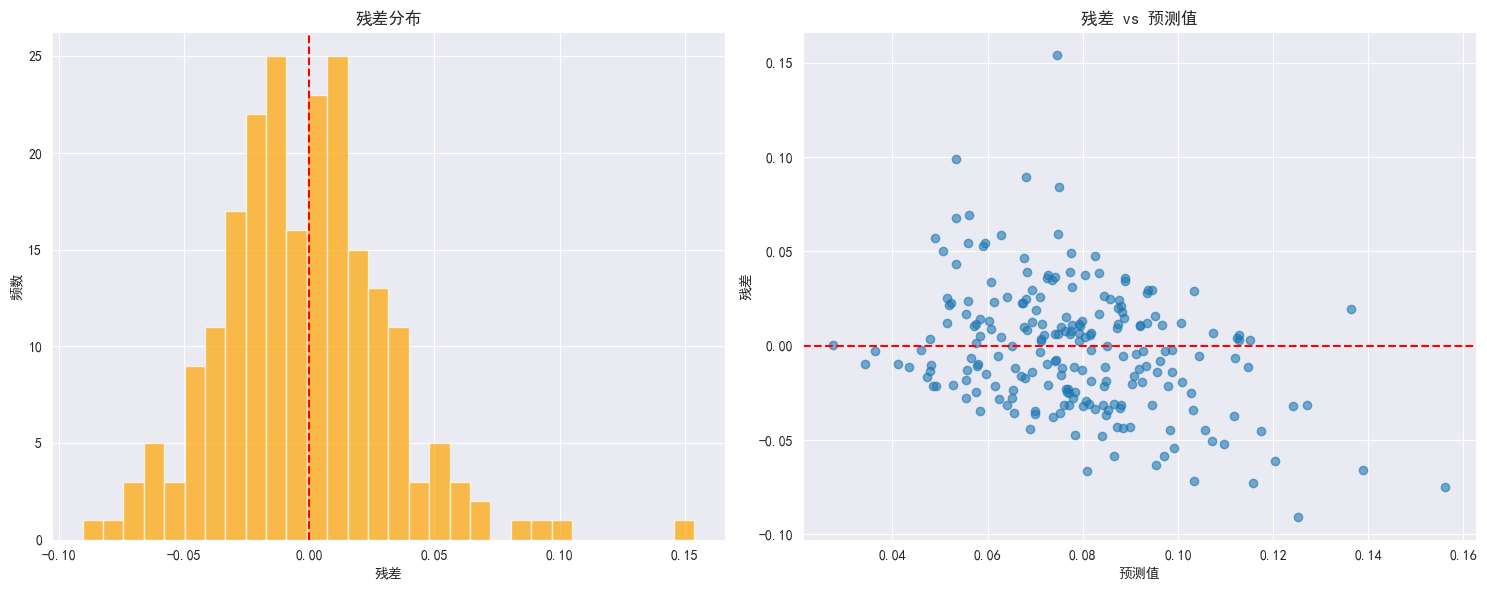


=== 预测结果可视化 ===


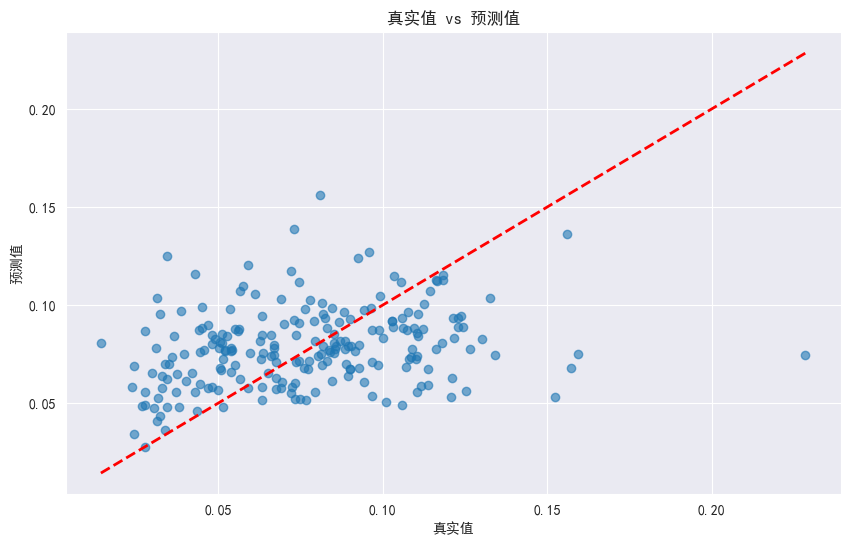


--- 额外拟合效果指标 (测试集) ---
MAE: 0.0257
MAPE: 42.84%
Explained Variance: -0.0603
Pearson 相关系数: r = 0.2624, p = 9.1719e-05

--- 与基线模型(均值预测)对比 ---
基线模型 RMSE: 0.0323
基线模型 R²: -0.0009
ΔR²: -0.0636  (正值代表优于基线)
ΔRMSE: +0.0010 (负值代表优于基线)

=== 分析完成 ===


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, explained_variance_score
from scipy.stats import pearsonr


# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 数据加载和预处理 ---
print("正在加载数据...")
file_path = '第一问.xlsx'
df = pd.read_excel(file_path)
df_clean = df.dropna(subset=['检测孕周', '孕妇BMI', 'Y染色体浓度'])
# df_clean = df_clean[df_clean['Y染色体浓度'].between(0, 0.15, inclusive='both')]
# df_clean = df_clean[df_clean['检测孕周'].between(10,25, inclusive='both')]
# df_clean = df_clean[df_clean['孕妇BMI'].between(25,40, inclusive='both')]

# --- 2. 探索性数据分析 ---
print("\n=== 探索性数据分析 ===")

# 基本统计信息
print("\n数值变量描述性统计:")
print(df_clean[['检测孕周', '孕妇BMI', 'Y染色体浓度']].describe())

# 相关性分析
correlation_matrix = df_clean[['检测孕周', '孕妇BMI', 'Y染色体浓度']].corr()
print("\n相关性矩阵:")
print(correlation_matrix)

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 分布图
axes[0, 0].hist(df_clean['Y染色体浓度'], bins=30, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Y染色体浓度分布')
axes[0, 0].set_xlabel('Y染色体浓度')
axes[0, 0].set_ylabel('频数')

axes[0, 1].hist(df_clean['孕妇BMI'], bins=30, alpha=0.7, color='lightgreen')
axes[0, 1].set_title('孕妇BMI分布')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('频数')

# 散点图
axes[1, 0].scatter(df_clean['检测孕周'], df_clean['Y染色体浓度'], alpha=0.6)
axes[1, 0].set_title('检测孕周 vs Y染色体浓度')
axes[1, 0].set_xlabel('检测孕周')
axes[1, 0].set_ylabel('Y染色体浓度')

axes[1, 1].scatter(df_clean['孕妇BMI'], df_clean['Y染色体浓度'], alpha=0.6)
axes[1, 1].set_title('孕妇BMI vs Y染色体浓度')
axes[1, 1].set_xlabel('孕妇BMI')
axes[1, 1].set_ylabel('Y染色体浓度')

plt.tight_layout()
plt.show()

# --- 3. 建模准备 ---
X = df_clean[['检测孕周', '孕妇BMI']]
y = df_clean['Y染色体浓度']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# --- 4. 训练随机森林模型 ---
print("\n=== 训练随机森林模型 ===")

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1  # 使用所有CPU核心
)

rf_model.fit(X_train, y_train)

# --- 5. 模型评估 ---
# 训练集性能
y_train_pred = rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# 测试集性能
y_test_pred = rf_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n--- 模型性能评估 ---")
print(f"训练集 R²: {train_r2:.4f}")
print(f"训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 R²: {test_r2:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")

# 交叉验证
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"\n5折交叉验证 R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# --- 6. 特征重要性分析 ---
print("\n=== 特征重要性分析 ===")

# 传统特征重要性
feature_importance = rf_model.feature_importances_
features = X.columns

print("\n1. 传统特征重要性:")
for i, feature in enumerate(features):
    print(f"  {feature}: {feature_importance[i]:.4f}")

# 排列重要性
perm_importance = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42
)

print("\n2. 排列重要性 (基于测试集):")
for i, feature in enumerate(features):
    print(f"  {feature}: {perm_importance.importances_mean[i]:.4f} "
          f"(±{perm_importance.importances_std[i]:.4f})")

# 可视化特征重要性
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 传统特征重要性
ax1.barh(features, feature_importance)
ax1.set_title('传统特征重要性')
ax1.set_xlabel('重要性得分')

# 排列重要性
ax2.barh(features, perm_importance.importances_mean)
ax2.set_title('排列重要性')
ax2.set_xlabel('重要性得分')

plt.tight_layout()
plt.show()

# --- 7. 部分依赖图 (替代SHAP依赖图) ---
print("\n=== 部分依赖分析 ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 检测孕周的部分依赖
PartialDependenceDisplay.from_estimator(
    rf_model, X, ['检测孕周'], ax=axes[0]
)
axes[0].set_title('检测孕周的部分依赖图')

# 孕妇BMI的部分依赖
PartialDependenceDisplay.from_estimator(
    rf_model, X, ['孕妇BMI'], ax=axes[1]
)
axes[1].set_title('孕妇BMI的部分依赖图')

plt.tight_layout()
plt.show()

# --- 8. 残差分析 ---
print("\n=== 残差分析 ===")

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 残差分布
axes[0].hist(residuals, bins=30, alpha=0.7, color='orange')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('残差分布')
axes[0].set_xlabel('残差')
axes[0].set_ylabel('频数')

# 残差 vs 预测值
axes[1].scatter(y_test_pred, residuals, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('残差 vs 预测值')
axes[1].set_xlabel('预测值')
axes[1].set_ylabel('残差')

plt.tight_layout()
plt.show()

# --- 9. 预测结果可视化 ---
print("\n=== 预测结果可视化 ===")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.title('真实值 vs 预测值')
plt.show()

# === 额外拟合效果指标 ===
mae_test = mean_absolute_error(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
evs_test = explained_variance_score(y_test, y_test_pred)
pearson_r, pearson_p = pearsonr(y_test, y_test_pred)

print("\n--- 额外拟合效果指标 (测试集) ---")
print(f"MAE: {mae_test:.4f}")
print(f"MAPE: {mape_test:.2f}%")
print(f"Explained Variance: {evs_test:.4f}")
print(f"Pearson 相关系数: r = {pearson_r:.4f}, p = {pearson_p:.4e}")

# === 与基线模型(均值预测)对比 ===
y_mean_pred = np.repeat(np.mean(y_train), len(y_test))
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_mean_pred))
baseline_r2 = r2_score(y_test, y_mean_pred)
print("\n--- 与基线模型(均值预测)对比 ---")
print(f"基线模型 RMSE: {baseline_rmse:.4f}")
print(f"基线模型 R²: {baseline_r2:.4f}")
print(f"ΔR²: {test_r2 - baseline_r2:+.4f}  (正值代表优于基线)")
print(f"ΔRMSE: {test_rmse - baseline_rmse:+.4f} (负值代表优于基线)")

print("\n=== 分析完成 ===")

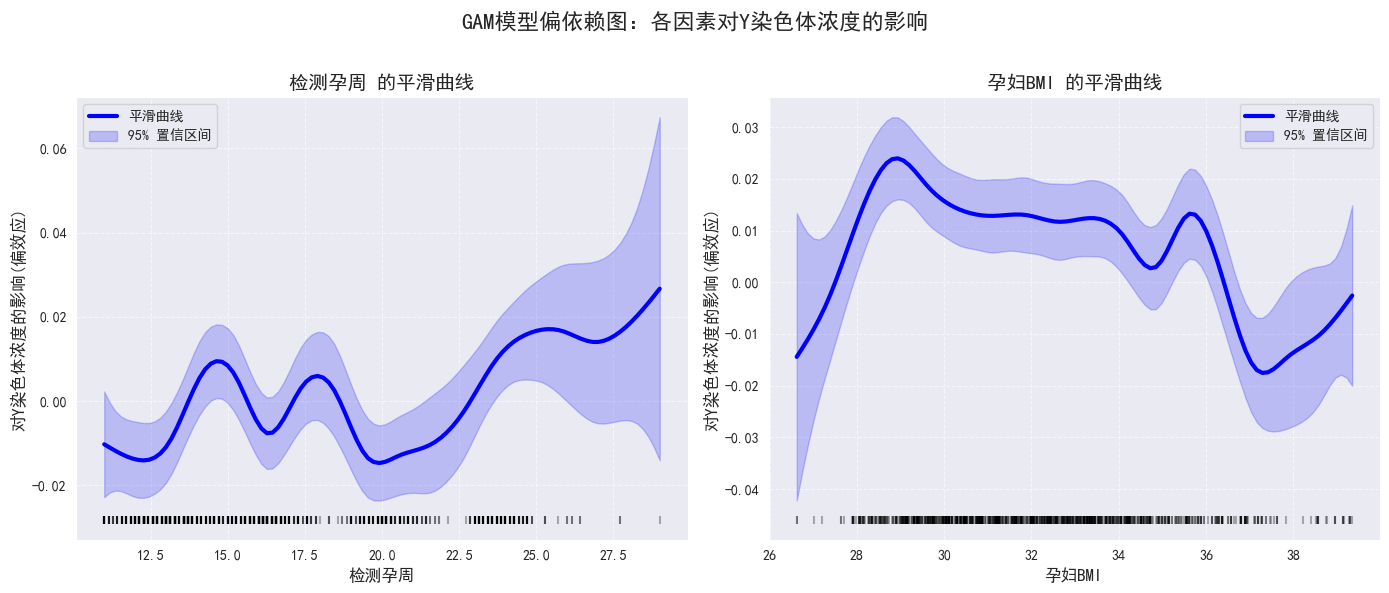

伪R平方 (Pseudo R-Squared): 0.1487
AIC (赤池信息准则): 1193736.44
GCV (广义交叉验证得分): 0.0009
-------------------------
各变量的有效自由度 (EDoF) 和 p值:
  - 检测孕周 (s(0)):
    p 值: 4.44e-16
  - 孕妇BMI (s(1)):
    p 值: 8.85e-10
注意: pyGAM官方提示，此处的p值可能偏小，仅供参考，但极小值通常意味着显著。


In [13]:
import matplotlib.pyplot as plt
import warnings
from pygam import LinearGAM, s
import pandas as pd

# --- 1. 环境与数据准备 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore", message=".*p-values computed in this summary.*")

# 读取数据
df = pd.read_excel("第一问.xlsx")
df.dropna(subset=['检测孕周', '孕妇BMI', 'Y染色体浓度'], inplace=True)

X = df[['检测孕周', '孕妇BMI']].values
y = df['Y染色体浓度'].values
feature_names = ['检测孕周', '孕妇BMI']

# --- 2. 建模与拟合 ---
gam = LinearGAM(s(0) + s(1)).fit(X, y)

# ===================================================================
# 3. 可视化：绘制偏依赖图
# ===================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GAM模型偏依赖图：各因素对Y染色体浓度的影响', fontsize=16)

for i, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, color='b', linewidth=3, label='平滑曲线')
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='b', alpha=0.2, label='95% 置信区间')
    ax.scatter(X[:, i], [ax.get_ylim()[0]] * len(X), marker='|', alpha=0.3, color='k')

    ax.set_xlabel(feature_names[i], fontsize=12)
    ax.set_ylabel('对Y染色体浓度的影响(偏效应)', fontsize=12)
    ax.set_title(f'{feature_names[i]} 的平滑曲线', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']
aic = gam.statistics_['AIC']
gcv = gam.statistics_['GCV']

print(f"伪R平方 (Pseudo R-Squared): {pseudo_r2:.4f}")
print(f"AIC (赤池信息准则): {aic:.2f}")
print(f"GCV (广义交叉验证得分): {gcv:.4f}")
print("-" * 25)

p_values = gam.statistics_['p_values']

print("各变量的有效自由度 (EDoF) 和 p值:")
for i, name in enumerate(feature_names):
    print(f"  - {name} (s({i})):")
    print(f"    p 值: {p_values[i]:.2e}")

print("注意: pyGAM官方提示，此处的p值可能偏小，仅供参考，但极小值通常意味着显著。")
print("="*50)

数据规模：1082 条观测，267 位孕妇


C:\Users\yqx\.virtualenvs\2025summer-JaSMG-jR\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== 混合效应模型拟合完成 ===

=== 混合效应模型结果（中文） ===
变量: Intercept
  系数估计: 0.0251
  p值: 0.0000  -> 显著
  95%置信区间: (0.0187, 0.0314)

变量: t
  系数估计: 0.0031
  p值: 0.0000  -> 显著
  95%置信区间: (0.0028, 0.0034)

变量: BMI_c
  系数估计: -0.0026
  p值: 0.0123  -> 显著
  95%置信区间: (-0.0046, -0.0006)

变量: t:BMI_c
  系数估计: 0.0001
  p值: 0.1770  -> 不显著
  95%置信区间: (-0.0000, 0.0002)

变量: Group Var
  系数估计: 2.8225
  p值: 0.0000  -> 显著
  95%置信区间: (2.2135, 3.4314)

固定效应拟合方程（含随机截距 u_i）：
y = 0.0251 + 0.0031 * t + -0.0026 * BMI_c + 0.0001 * t * BMI_c + u_i + ε


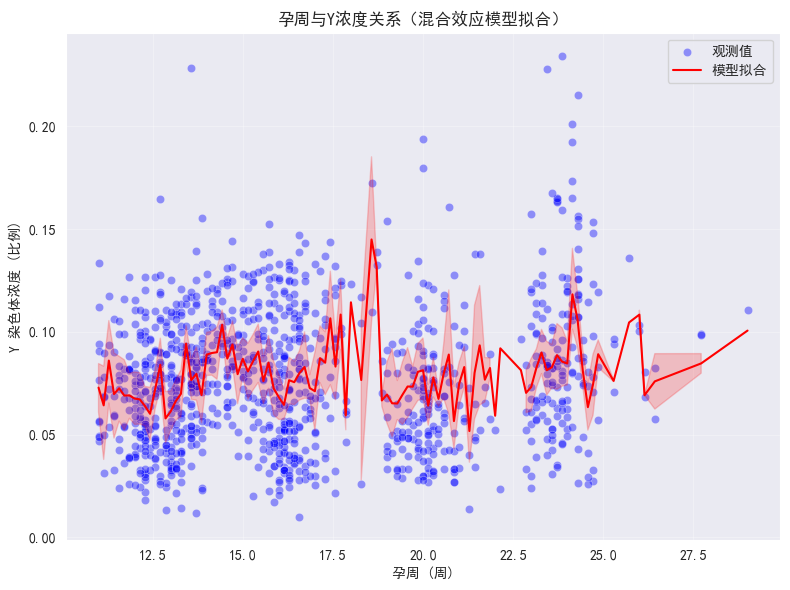

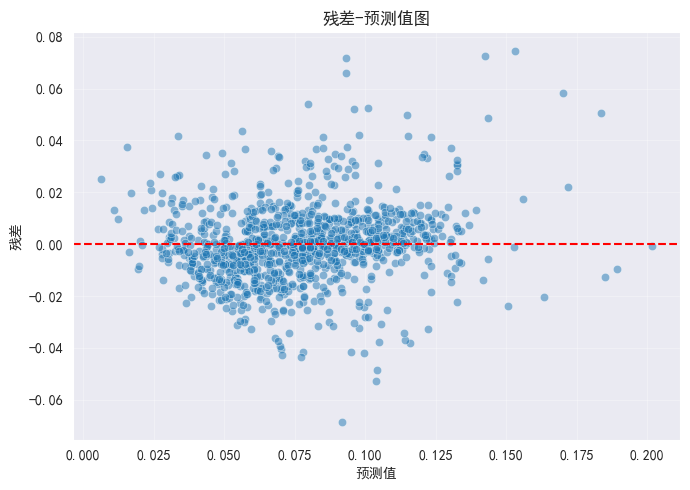

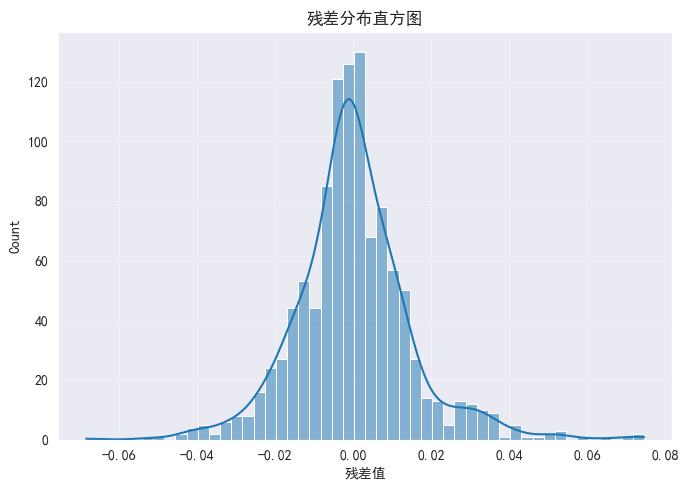

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ===== 1. 数据读取与预处理 =====
EXCEL_PATH = r"第一问.xlsx"

df = pd.read_excel(EXCEL_PATH)
df = df.rename(columns={
    '孕妇代码': 'id',
    '检测孕周': 't',
    '孕妇BMI': 'BMI',
    'Y染色体浓度': 'y'
})
df = df.dropna(subset=['id', 't', 'BMI', 'y'])

# 百分数转换为小数
if df['y'].max() > 1.5:
    print("检测到 y 可能是百分数，已除以 100 处理为比例")
    df['y'] = df['y'] / 100

# 过滤一下不合理值
df = df[(df['t'] > 0) & (df['t'] < 45) & (df['BMI'] > 10) & (df['BMI'] < 60)]

# 中心化 BMI
df['BMI_c'] = df['BMI'] - df['BMI'].mean()

print(f"数据规模：{len(df)} 条观测，{df['id'].nunique()} 位孕妇")

# ===== 2. 建立线性混合效应模型（随机截距） =====
model = smf.mixedlm("y ~ t + BMI_c + t:BMI_c", data=df, groups=df["id"])
result = model.fit()
print("\n=== 混合效应模型拟合完成 ===")

# ===== 3. 中文输出关键结果 =====
params = result.params
conf_int = result.conf_int()
pvalues = result.pvalues

print("\n=== 混合效应模型结果（中文） ===")
for name in params.index:
    est = params[name]
    ci_low, ci_up = conf_int.loc[name]
    pval = pvalues[name]
    sig = "显著" if pval < 0.05 else "不显著"
    print(f"变量: {name}")
    print(f"  系数估计: {est:.4f}")
    print(f"  p值: {pval:.4f}  -> {sig}")
    print(f"  95%置信区间: ({ci_low:.4f}, {ci_up:.4f})\n")

# ===== 4. 拟合方程 =====
# 基于固定效应部分写出回归方程
b0 = params["Intercept"]
b1 = params["t"]
b2 = params["BMI_c"]
b3 = params["t:BMI_c"]

eqn = f"y = {b0:.4f} + {b1:.4f} * t + {b2:.4f} * BMI_c + {b3:.4f} * t * BMI_c + u_i + ε"
print("固定效应拟合方程（含随机截距 u_i）：")
print(eqn)

# ===== 5. 绘制拟合效果图 =====
df["y_pred"] = result.fittedvalues

plt.figure(figsize=(8,6))
sns.scatterplot(x="t", y="y", data=df, alpha=0.4, label="观测值", color="blue")
sns.lineplot(x="t", y="y_pred", data=df.sort_values("t"),
             color="red", label="模型拟合")
plt.xlabel("孕周 (周)")
plt.ylabel("Y 染色体浓度 (比例)")
plt.title("孕周与Y浓度关系（混合效应模型拟合）")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 6. 残差分析 =====
df["residuals"] = df["y"] - df["y_pred"]

# 残差-预测值图
plt.figure(figsize=(7,5))
sns.scatterplot(x="y_pred", y="residuals", data=df, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("预测值")
plt.ylabel("残差")
plt.title("残差-预测值图")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 残差分布直方图
plt.figure(figsize=(7,5))
sns.histplot(df["residuals"], kde=True)
plt.xlabel("残差值")
plt.title("残差分布直方图")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


数据规模：1082 条观测，267 位孕妇


C:\Users\yqx\.virtualenvs\2025summer-JaSMG-jR\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== 混合效应模型拟合完成 ===

=== 混合效应模型结果（中文） ===
变量: Intercept
  系数估计: 0.0251
  p值: 0.0000  -> 显著
  95%置信区间: (0.0187, 0.0314)

变量: t
  系数估计: 0.0031
  p值: 0.0000  -> 显著
  95%置信区间: (0.0028, 0.0034)

变量: BMI_c
  系数估计: -0.0026
  p值: 0.0123  -> 显著
  95%置信区间: (-0.0046, -0.0006)

变量: t:BMI_c
  系数估计: 0.0001
  p值: 0.1770  -> 不显著
  95%置信区间: (-0.0000, 0.0002)

变量: Group Var
  系数估计: 2.8225
  p值: 0.0000  -> 显著
  95%置信区间: (2.2135, 3.4314)

固定效应拟合方程（含随机截距 u_i）：
y = 0.0251 + 0.0031 * t + -0.0026 * BMI_c + 0.0001 * t * BMI_c + u_i + ε


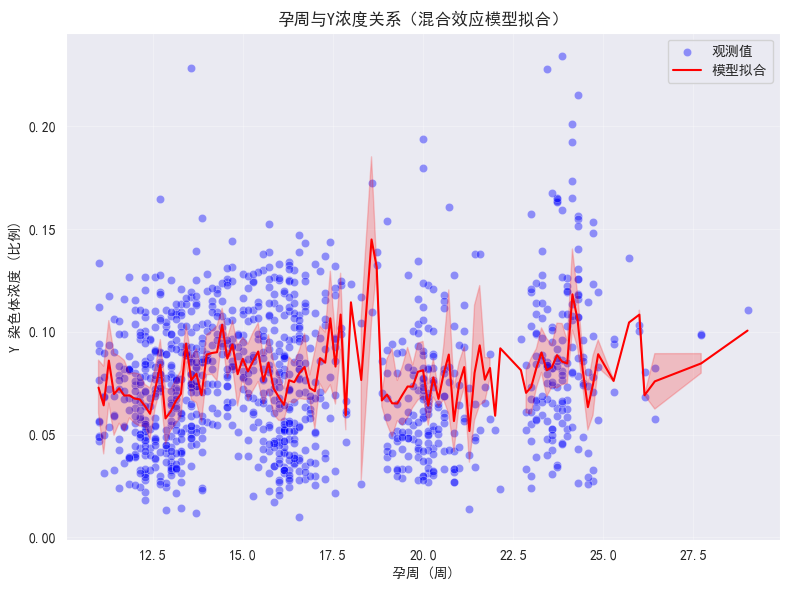

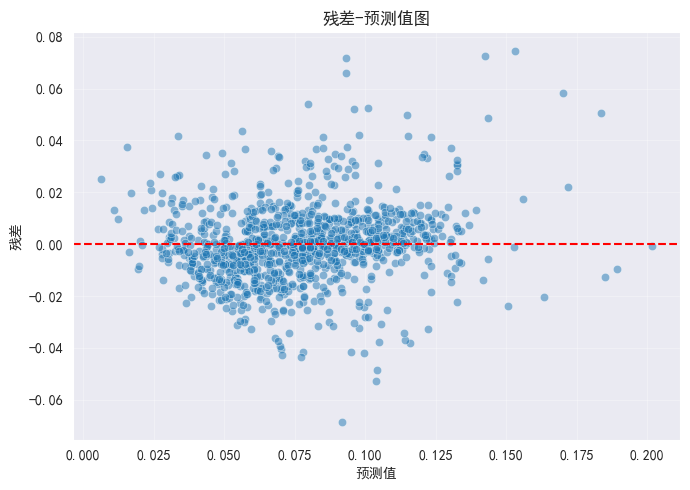

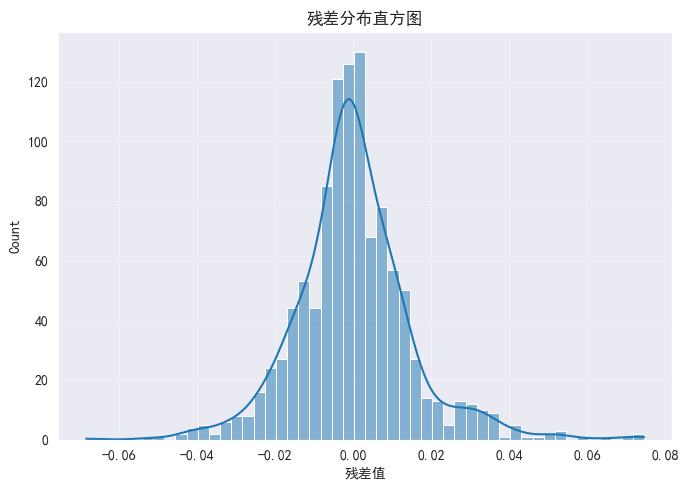


=== 模型拟合效果 ===
R²（总解释度）: 0.7985 -> 模型解释了 79.85% 的浓度变异
RMSE（均方根误差）: 0.0150 -> 平均预测误差约 1.50% 浓度

=== 参数显著性检验 ===
Intercept: 系数=0.0251  p值=1.458e-14 (显著)  95%CI=(0.0187, 0.0314)
t: 系数=0.0031  p值=4.301e-84 (显著)  95%CI=(0.0028, 0.0034)
BMI_c: 系数=-0.0026  p值=0.01229 (显著)  95%CI=(-0.0046, -0.0006)
t:BMI_c: 系数=0.0001  p值=0.177 (不显著)  95%CI=(-0.0000, 0.0002)
Group Var: 系数=2.8225  p值=1.046e-19 (显著)  95%CI=(2.2135, 3.4314)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ===== 1. 数据读取与预处理 =====
EXCEL_PATH = r"第一问.xlsx"

df = pd.read_excel(EXCEL_PATH)
df = df.rename(columns={
    '孕妇代码': 'id',
    '检测孕周': 't',
    '孕妇BMI': 'BMI',
    'Y染色体浓度': 'y'
})
df = df.dropna(subset=['id', 't', 'BMI', 'y'])

# 百分数转换为小数
if df['y'].max() > 1.5:
    print("检测到 y 可能是百分数，已除以 100 处理为比例")
    df['y'] = df['y'] / 100

# 过滤一下不合理值
df = df[(df['t'] > 0) & (df['t'] < 45) & (df['BMI'] > 10) & (df['BMI'] < 60)]

# 中心化 BMI
df['BMI_c'] = df['BMI'] - df['BMI'].mean()

print(f"数据规模：{len(df)} 条观测，{df['id'].nunique()} 位孕妇")

# ===== 2. 建立线性混合效应模型（随机截距） =====
model = smf.mixedlm("y ~ t + BMI_c + t:BMI_c", data=df, groups=df["id"])
result = model.fit()
print("\n=== 混合效应模型拟合完成 ===")

# ===== 3. 中文输出关键结果 =====
params = result.params
conf_int = result.conf_int()
pvalues = result.pvalues

print("\n=== 混合效应模型结果（中文） ===")
for name in params.index:
    est = params[name]
    ci_low, ci_up = conf_int.loc[name]
    pval = pvalues[name]
    sig = "显著" if pval < 0.05 else "不显著"
    print(f"变量: {name}")
    print(f"  系数估计: {est:.4f}")
    print(f"  p值: {pval:.4f}  -> {sig}")
    print(f"  95%置信区间: ({ci_low:.4f}, {ci_up:.4f})\n")

# ===== 4. 拟合方程 =====
# 基于固定效应部分写出回归方程
b0 = params["Intercept"]
b1 = params["t"]
b2 = params["BMI_c"]
b3 = params["t:BMI_c"]

eqn = f"y = {b0:.4f} + {b1:.4f} * t + {b2:.4f} * BMI_c + {b3:.4f} * t * BMI_c + u_i + ε"
print("固定效应拟合方程（含随机截距 u_i）：")
print(eqn)

# ===== 5. 绘制拟合效果图 =====
df["y_pred"] = result.fittedvalues

plt.figure(figsize=(8,6))
sns.scatterplot(x="t", y="y", data=df, alpha=0.4, label="观测值", color="blue")
sns.lineplot(x="t", y="y_pred", data=df.sort_values("t"),
             color="red", label="模型拟合")
plt.xlabel("孕周 (周)")
plt.ylabel("Y 染色体浓度 (比例)")
plt.title("孕周与Y浓度关系（混合效应模型拟合）")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 6. 残差分析 =====
df["residuals"] = df["y"] - df["y_pred"]

# 残差-预测值图
plt.figure(figsize=(7,5))
sns.scatterplot(x="y_pred", y="residuals", data=df, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("预测值")
plt.ylabel("残差")
plt.title("残差-预测值图")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 残差分布直方图
plt.figure(figsize=(7,5))
sns.histplot(df["residuals"], kde=True)
plt.xlabel("残差值")
plt.title("残差分布直方图")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 计算拟合效果指标 =====
y_true = df["y"]
y_pred = result.fittedvalues  # 包括固定+随机效应的预测值

ss_res = ((y_true - y_pred) ** 2).sum()
ss_tot = ((y_true - y_true.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(((y_true - y_pred) ** 2).mean())

print(f"\n=== 模型拟合效果 ===")
print(f"R²（总解释度）: {r2:.4f} -> 模型解释了 {r2*100:.2f}% 的浓度变异")
print(f"RMSE（均方根误差）: {rmse:.4f} -> 平均预测误差约 {rmse*100:.2f}% 浓度")

# ===== 参数显著性统计（系数估计、p值、95%CI） =====
params = result.params
conf_int = result.conf_int()
pvalues = result.pvalues

print("\n=== 参数显著性检验 ===")
for name in params.index:
    est = params[name]
    ci_low, ci_up = conf_int.loc[name]
    pval = pvalues[name]
    sig = "显著" if pval < 0.05 else "不显著"
    print(f"{name}: 系数={est:.4f}  p值={pval:.4g} ({sig})  95%CI=({ci_low:.4f}, {ci_up:.4f})")
